#Import Data & EDA

In [57]:
import pandas as pd
# Unzipping the downloaded dataset
# Assuming 'insurance.csv' is the main data file within the zip archive
df = pd.read_csv('/content/cirrhosis.csv')


In [58]:
df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [59]:
df.shape

(418, 20)

In [60]:
df.columns

Index(['ID', 'N_Days', 'Status', 'Drug', 'Age', 'Sex', 'Ascites',
       'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol',
       'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets',
       'Prothrombin', 'Stage'],
      dtype='object')

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

In [62]:
df.describe()

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,418.000000,418.000000,418.000000,418.000000,284.000000,418.000000,310.000000,312.000000,312.000000,282.000000,407.000000,416.000000,412.000000
mean,209.500000,1917.782297,18533.351675,3.220813,369.510563,3.497440,97.648387,1982.655769,122.556346,124.702128,257.024570,10.731731,3.024272
std,120.810458,1104.672992,3815.845055,4.407506,231.944545,0.424972,85.613920,2140.388824,56.699525,65.148639,98.325585,1.022000,0.882042
min,1.000000,41.000000,9598.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,105.250000,1092.750000,15644.500000,0.800000,249.500000,3.242500,41.250000,871.500000,80.600000,84.250000,188.500000,10.000000,2.000000
50%,209.500000,1730.000000,18628.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000
75%,313.750000,2613.500000,21272.500000,3.400000,400.000000,3.770000,123.000000,1980.000000,151.900000,151.000000,318.000000,11.100000,4.000000
max,418.000000,4795.000000,28650.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


In [63]:
df.isnull().sum()

,0
ID,0
N_Days,0
Status,0
Drug,106
Age,0
Sex,0
Ascites,106
Hepatomegaly,106
Spiders,106
Edema,0


In [64]:
df.duplicated().sum()

np.int64(0)

In [65]:
print(df["Stage"].value_counts())

Stage
3.0    155
4.0    144
2.0     92
1.0     21
Name: count, dtype: int64


In [66]:
print(df["Stage"].value_counts(normalize=True) * 100)

Stage
3.0    37.621359
4.0    34.951456
2.0    22.330097
1.0     5.097087
Name: proportion, dtype: float64


# Data Cleaning

In [67]:
df = df.dropna(subset=['Stage'])


In [68]:
df.drop('ID',inplace=True,axis=1)

In [69]:
categorical_col=df.select_dtypes(include=object).columns
categorical_col


Index(['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema'], dtype='object')

In [70]:
numerical_col=df.select_dtypes(exclude=object).columns
numerical_col

Index(['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
       'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin',
       'Stage'],
      dtype='object')

In [71]:

for col in numerical_col:
    mean_value = df[col].mean()
    df[col] = df[col].fillna(mean_value)

In [72]:
for col in categorical_col:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Custom color palette (soft, muted, eye-friendly - no blue/green) ----
PALETTE = ["#C97B84", "#D4A574", "#B98EA3", "#A98467", "#E8B4A0", "#8C6A5D", "#CBA0AE", "#DDBB99"]

sns.set_theme(style="whitegrid")
sns.set_palette(PALETTE)

HEATMAP_CMAP = sns.diverging_palette(15, 300, s=55, l=75, as_cmap=True)  # soft, low-saturation
SEQ_CMAP = sns.light_palette("#C97B84", as_cmap=True)                    # soft dusty rose

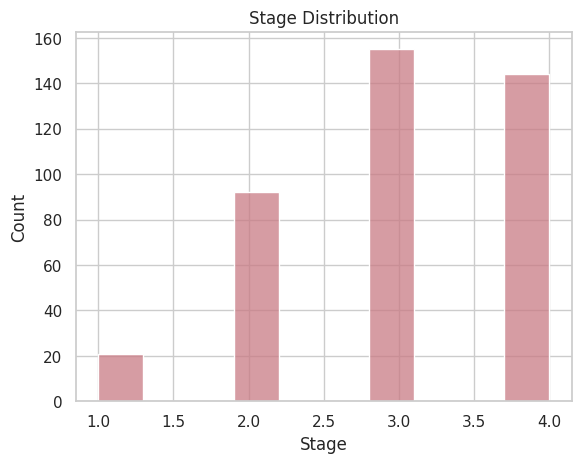

In [74]:
sns.histplot(df['Stage'], color=PALETTE[0])
plt.title("Stage Distribution")
plt.show()
#

**Insight:** Stage 3 and 4 make up ~72% of patients; Stage 1 is rare (only 21 cases). The target is imbalanced.

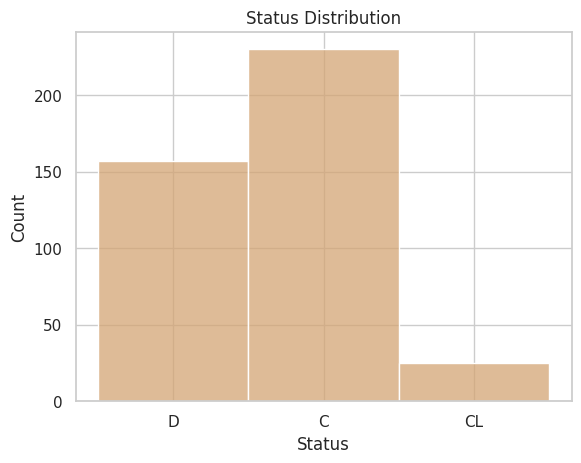

In [75]:
sns.histplot(df['Status'], color=PALETTE[1])
plt.title("Status Distribution")
plt.show()

**Insight:** Most patients are alive (`C`, ~55%), ~38% died (`D`), and only ~6% had a transplant (`CL`).

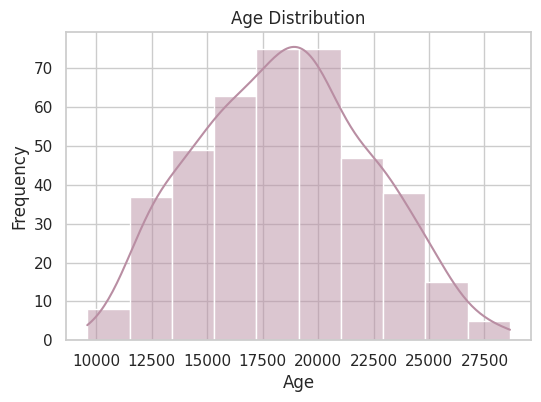

In [76]:
plt.figure(figsize=(6, 4))

sns.histplot(data=df, x="Age", bins=10, kde=True, color=PALETTE[2])

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**Insight:** Age ranges roughly 26-78 years, centered around ~50-51, close to a normal distribution.



# Checking Outliers for numerical

/tmp/ipykernel_873/3880121743.py:3: UserWarning: 
The palette list has fewer values (8) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df[numerical_col], palette=PALETTE)


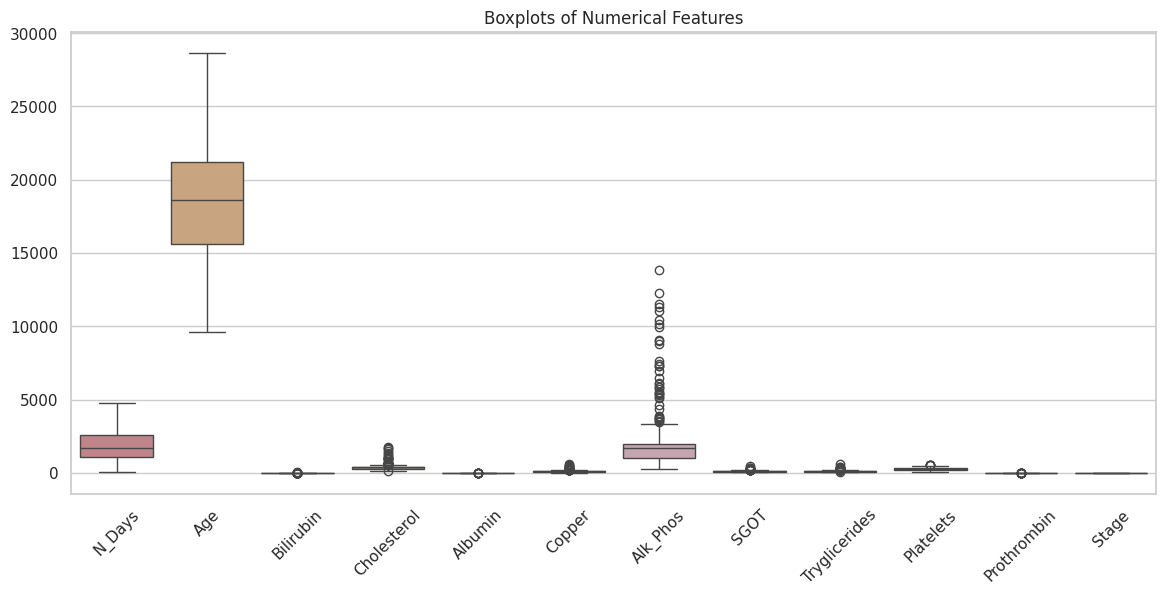

In [77]:
plt.figure(figsize=(14, 6))

sns.boxplot(data=df[numerical_col], palette=PALETTE)

plt.title("Boxplots of Numerical Features")
plt.xticks(rotation=45)
plt.show()

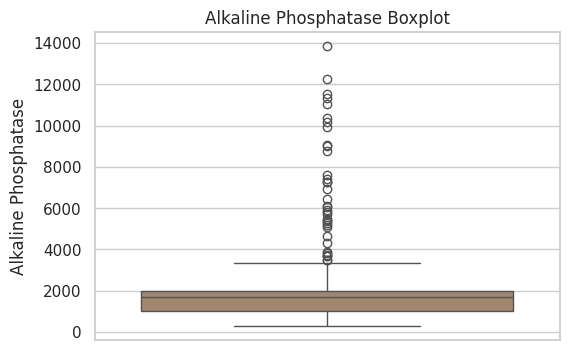

In [78]:
plt.figure(figsize=(6, 4))

sns.boxplot(data=df, y="Alk_Phos", color=PALETTE[3])

plt.title("Alkaline Phosphatase Boxplot")
plt.ylabel("Alkaline Phosphatase")
plt.show()

**Insight:** Several lab features (Bilirubin, Cholesterol, Alk_Phos, Copper) show heavy right-skew and outliers - expected for liver-disease markers, but worth watching during scaling/modeling.

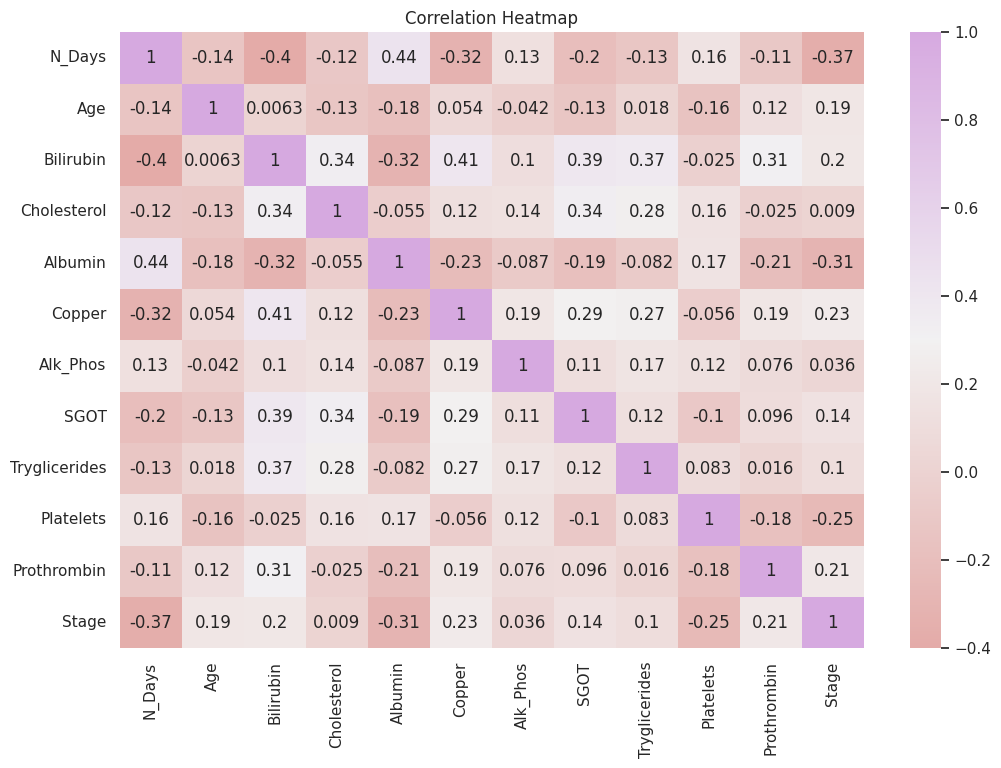

In [79]:
plt.figure(figsize=(12, 8))

correlation = df[numerical_col].corr()

sns.heatmap(correlation, annot=True, cmap=HEATMAP_CMAP)

plt.title("Correlation Heatmap")
plt.show()

**Insight:** `Albumin` correlates negatively with `Stage` (-0.31, lower albumin -> more advanced disease), while `Bilirubin`, `Copper`, and `Prothrombin` correlate positively (~0.2-0.27). This matches known liver-disease biology.

#  Checking relations with categorical


Status
C     230
D     157
CL     25
Name: count, dtype: int64
Status
C     55.825243
D     38.106796
CL     6.067961
Name: proportion, dtype: float64
------------------------------
Drug
D-penicillamine    258
Placebo            154
Name: count, dtype: int64
Drug
D-penicillamine    62.621359
Placebo            37.378641
Name: proportion, dtype: float64
------------------------------
Sex
F    368
M     44
Name: count, dtype: int64
Sex
F    89.320388
M    10.679612
Name: proportion, dtype: float64
------------------------------
Ascites
N    388
Y     24
Name: count, dtype: int64
Ascites
N    94.174757
Y     5.825243
Name: proportion, dtype: float64
------------------------------
Hepatomegaly
Y    260
N    152
Name: count, dtype: int64
Hepatomegaly
Y    63.106796
N    36.893204
Name: proportion, dtype: float64
------------------------------
Spiders
N    322
Y     90
Name: count, dtype: int64
Spiders
N    78.15534
Y    21.84466
Name: proportion, dtype: float64
-----------------------------

/tmp/ipykernel_873/863110952.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette=PALETTE)
/tmp/ipykernel_873/863110952.py:12: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.countplot(data=df, x=col, ax=ax, palette=PALETTE)
/tmp/ipykernel_873/863110952.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette=PALETTE)
/tmp/ipykernel_873/863110952.py:12: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.countplot(data=df, x=col, ax=ax, palette=PALETTE)
/tmp/ipykernel_873/863110952.py:12: FutureWarning: 

Passing `palette` without

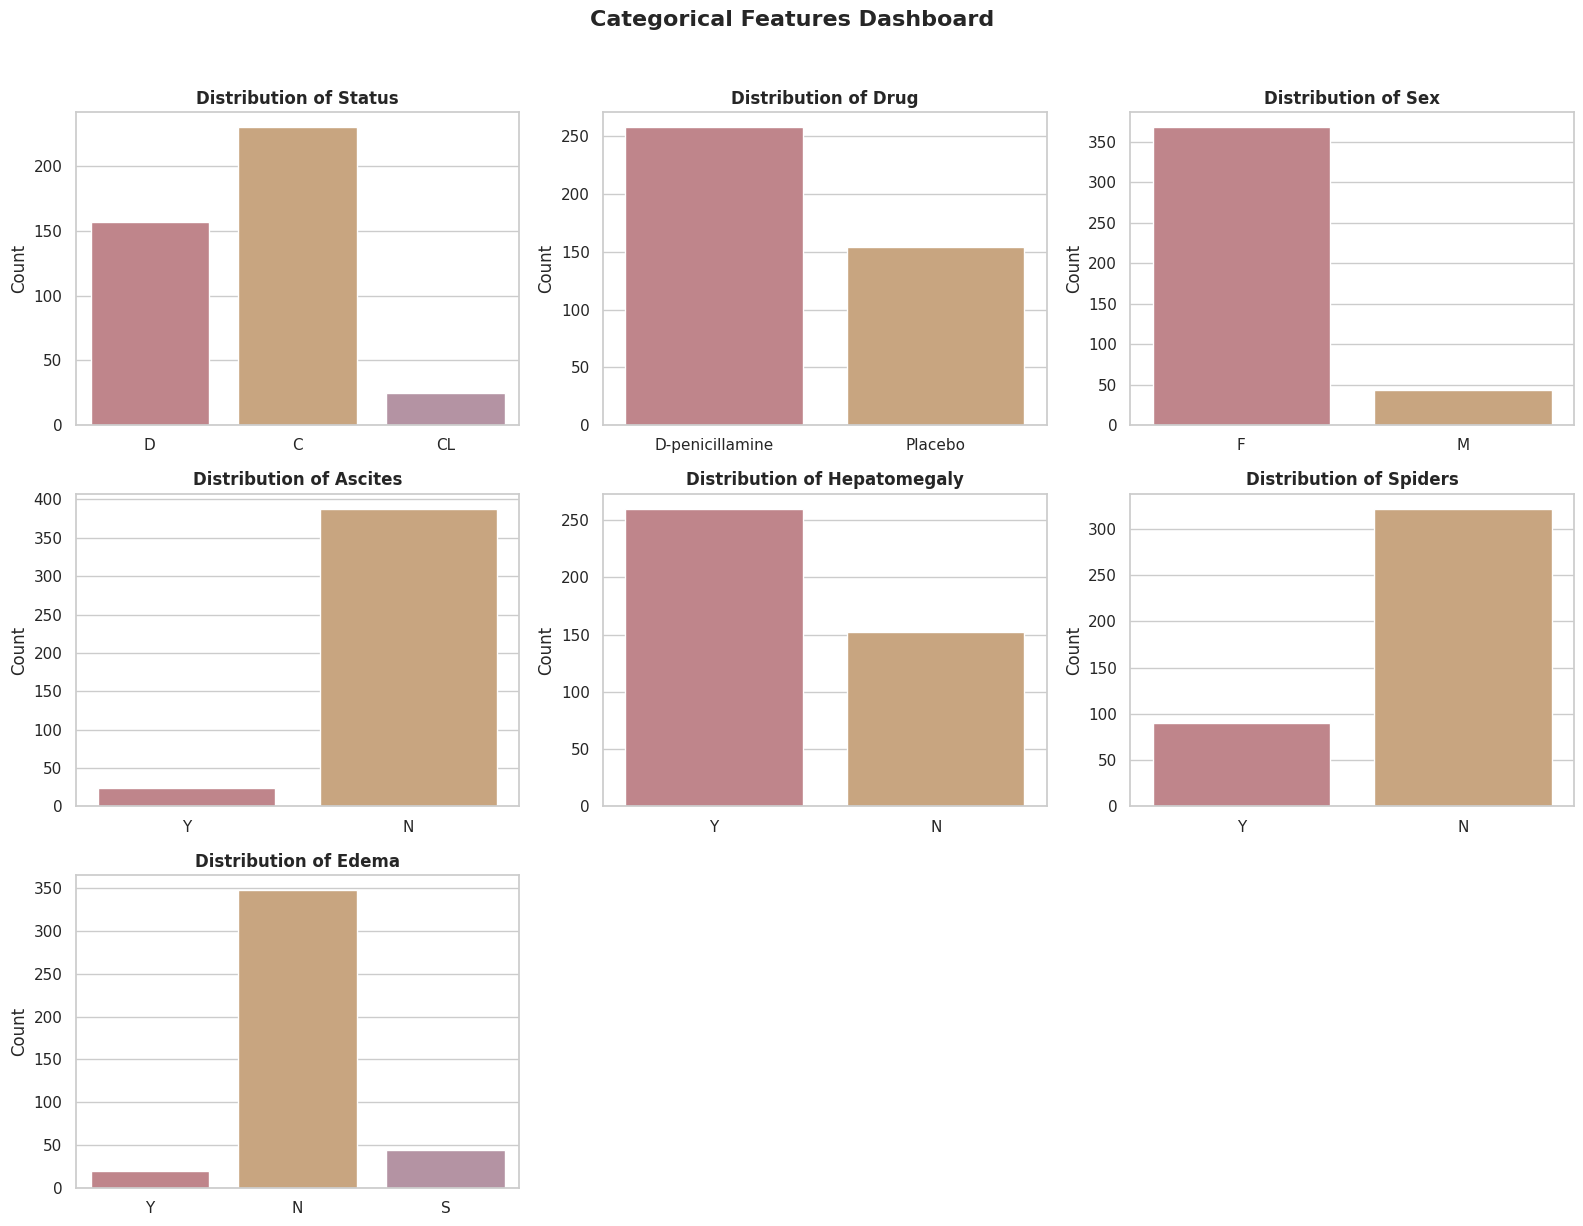

In [80]:
# Print frequency + percentage breakdown for each categorical column
for col in categorical_col:
     print(df[col].value_counts())
     print(df[col].value_counts(normalize=True) * 100)
     print("-" * 30)

# Categorical Features Dashboard (all charts combined in one figure)
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for ax, col in zip(axes, categorical_col):
    sns.countplot(data=df, x=col, ax=ax, palette=PALETTE)
    ax.set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")

for ax in axes[len(categorical_col):]:
    ax.axis("off")

plt.suptitle("Categorical Features Dashboard", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Insight:** Dataset skews female (~89%). Most patients don't show Ascites (92%) or Spiders (71%), but Hepatomegaly is close to a 50/50 split. Edema is mostly absent (85%).

## Feature engineering

In [81]:
df['Age_Years'] = (df['Age'] / 365.25).astype(int)

In [82]:
threshold = df['Bilirubin'].quantile(0.75)  # = 3.4

df['High_Severity'] = ((df['Bilirubin'] > threshold) & (df['Ascites'] == 'Y')).astype(int)

print(df['High_Severity'].value_counts())
pd.crosstab(df['High_Severity'], df['Stage'])

High_Severity
0    397
1     15
Name: count, dtype: int64


Stage,1.0,2.0,3.0,4.0
High_Severity,,,,
0,21,91,155,130
1,0,1,0,14


In [83]:
signs = ['Ascites', 'Hepatomegaly', 'Spiders', 'Edema']
df['Signs_Count'] = df[signs].apply(lambda row: (row == 'Y').sum(), axis=1)
#
print(df['Signs_Count'].value_counts())
pd.crosstab(df['Signs_Count'], df['Stage'])

Signs_Count
1    208
0    125
2     58
3     14
4      7
Name: count, dtype: int64


Stage,1.0,2.0,3.0,4.0
Signs_Count,,,,
0,15,43,54,13
1,6,44,81,77
2,0,4,19,35
3,0,0,1,13
4,0,1,0,6


In [84]:
df['Low_Albumin'] = (df['Albumin'] < 2.8).astype(int)
pd.crosstab(df['Low_Albumin'], df['Stage'])

Stage,1.0,2.0,3.0,4.0
Low_Albumin,,,,
0,21,90,153,126
1,0,2,2,18


# Preprocessing & Encoding

In [85]:
# Binary Yes/No columns -> 0/1
binary_map = {'Y': 1, 'N': 0}
for col in ['Ascites', 'Hepatomegaly', 'Spiders']:
    df[col] = df[col].map(binary_map)

# Sex -> 0/1
df['Sex'] = df['Sex'].map({'M': 1, 'F': 0})

# Edema has 3 ordered levels (N < S < Y) -> ordinal encoding
df['Edema'] = df['Edema'].map({'N': 0, 'S': 1, 'Y': 2})

df[['Ascites', 'Hepatomegaly', 'Spiders', 'Sex', 'Edema']].head()

,Ascites,Hepatomegaly,Spiders,Sex,Edema
0,1,1,1,0,2
1,0,1,1,0,0
2,0,0,0,1,1
3,0,1,1,0,1
4,0,1,1,0,0


In [86]:
# Drug and Status are nominal (no natural order) -> One-Hot Encoding
df = pd.get_dummies(df, columns=['Drug', 'Status'], drop_first=True)
df.head()

,N_Days,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,...,Platelets,Prothrombin,Stage,Age_Years,High_Severity,Signs_Count,Low_Albumin,Drug_Placebo,Status_CL,Status_D
0,400,21464,0,1,1,1,2,14.5,261.0,2.60,...,190.0,12.2,4.0,58,1,4,1,False,False,True
1,4500,20617,0,0,1,1,0,1.1,302.0,4.14,...,221.0,10.6,3.0,56,0,2,0,False,False,False
2,1012,25594,1,0,0,0,1,1.4,176.0,3.48,...,151.0,12.0,4.0,70,0,0,0,False,False,True
3,1925,19994,0,0,1,1,1,1.8,244.0,2.54,...,183.0,10.3,4.0,54,0,2,1,False,False,True
4,1504,13918,0,0,1,1,0,3.4,279.0,3.53,...,136.0,10.9,3.0,38,0,2,0,True,True,False


**Note:** `Status` reflects the trial's final outcome (Death / Censored / Liver transplant) and may be strongly correlated with `Stage`, bordering on data leakage if the goal is early-stage prediction. It is kept as a feature for now, and its importance is checked later — if it dominates the model's decisions, it should be dropped and the model retrained.

#  Prepare Data for Modeling (Target --> Stage)

In [87]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Stage'])
# XGBoost requires class labels starting at 0, so shift Stage (1-4) -> (0-3).
# We keep a mapping to translate predictions back to the original 1-4 labels.
y = df['Stage'].astype(int) - 1
stage_labels = {0: 1, 1: 2, 2: 3, 3: 4}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print(y_train.value_counts(normalize=True))

Train shape: (329, 23)
Test shape: (83, 23)
Stage
2    0.376900
3    0.349544
1    0.221884
0    0.051672
Name: proportion, dtype: float64


In [88]:
from sklearn.preprocessing import StandardScaler

numeric_features = ['N_Days', 'Age', 'Age_Years', 'Bilirubin', 'Cholesterol', 'Albumin',
                     'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

X_train_scaled.head()

,N_Days,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,...,Tryglicerides,Platelets,Prothrombin,Age_Years,High_Severity,Signs_Count,Low_Albumin,Drug_Placebo,Status_CL,Status_D
223,0.022325,-1.197396,0,0,0,0,0,-0.484727,-0.310559,0.437452,...,-0.423390,0.554535,-0.986300,-1.212273,0,0,0,False,False,False
239,-0.081367,0.510364,0,0,0,0,0,-0.616307,-0.697219,0.580991,...,0.250913,0.736570,-0.609385,0.546013,0,0,0,False,False,False
386,-0.243271,-0.182167,0,0,1,0,1,2.278457,-0.006702,-1.141477,...,-0.002800,-0.259270,-0.797842,-0.235448,0,1,0,False,False,False
359,-1.039146,1.285109,0,0,1,0,0,-0.309287,-0.006702,-0.782629,...,-0.002800,-0.794668,-0.326698,1.327473,0,1,0,False,False,True
272,-0.329680,-0.336687,0,0,0,1,0,-0.221567,-0.215149,-0.041011,...,-0.157218,-0.591217,-1.080529,-0.333130,0,1,0,True,False,False


# Baseline Modeling

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

models = {}
results = []

In [90]:
# Logistic Regression
model_logistic_regression = LogisticRegression(max_iter=2000, random_state=42)
model_logistic_regression.fit(X_train_scaled, y_train)
preds_logistic_regression = model_logistic_regression.predict(X_test_scaled)

acc_logistic_regression = accuracy_score(y_test, preds_logistic_regression)
f1_logistic_regression = f1_score(y_test, preds_logistic_regression, average='macro')
cv_logistic_regression = cross_val_score(model_logistic_regression, X_train_scaled, y_train, cv=5, scoring='f1_macro').mean()

models["Logistic Regression"] = model_logistic_regression
results.append({"Model": "Logistic Regression", "Test Accuracy": acc_logistic_regression, "Test F1-macro": f1_logistic_regression, "CV F1-macro": cv_logistic_regression})

In [91]:
# Decision Tree
model_decision_tree = DecisionTreeClassifier(random_state=42)
model_decision_tree.fit(X_train_scaled, y_train)
preds_decision_tree = model_decision_tree.predict(X_test_scaled)

acc_decision_tree = accuracy_score(y_test, preds_decision_tree)
f1_decision_tree = f1_score(y_test, preds_decision_tree, average='macro')
cv_decision_tree = cross_val_score(model_decision_tree, X_train_scaled, y_train, cv=5, scoring='f1_macro').mean()

models["Decision Tree"] = model_decision_tree
results.append({"Model": "Decision Tree", "Test Accuracy": acc_decision_tree, "Test F1-macro": f1_decision_tree, "CV F1-macro": cv_decision_tree})

In [92]:
# Random Forest
model_random_forest = RandomForestClassifier(n_estimators=300, random_state=42)
model_random_forest.fit(X_train_scaled, y_train)
preds_random_forest = model_random_forest.predict(X_test_scaled)

acc_random_forest = accuracy_score(y_test, preds_random_forest)
f1_random_forest = f1_score(y_test, preds_random_forest, average='macro')
cv_random_forest = cross_val_score(model_random_forest, X_train_scaled, y_train, cv=5, scoring='f1_macro').mean()

models["Random Forest"] = model_random_forest
results.append({"Model": "Random Forest", "Test Accuracy": acc_random_forest, "Test F1-macro": f1_random_forest, "CV F1-macro": cv_random_forest})

In [93]:
# Gradient Boosting
model_gradient_boosting = GradientBoostingClassifier(random_state=42)
model_gradient_boosting.fit(X_train_scaled, y_train)
preds_gradient_boosting = model_gradient_boosting.predict(X_test_scaled)

acc_gradient_boosting = accuracy_score(y_test, preds_gradient_boosting)
f1_gradient_boosting = f1_score(y_test, preds_gradient_boosting, average='macro')
cv_gradient_boosting = cross_val_score(model_gradient_boosting, X_train_scaled, y_train, cv=5, scoring='f1_macro').mean()

models["Gradient Boosting"] = model_gradient_boosting
results.append({"Model": "Gradient Boosting", "Test Accuracy": acc_gradient_boosting, "Test F1-macro": f1_gradient_boosting, "CV F1-macro": cv_gradient_boosting})

In [94]:
# XGBoost
model_xgboost = XGBClassifier(random_state=42, eval_metric='mlogloss')
model_xgboost.fit(X_train_scaled, y_train)
preds_xgboost = model_xgboost.predict(X_test_scaled)

acc_xgboost = accuracy_score(y_test, preds_xgboost)
f1_xgboost = f1_score(y_test, preds_xgboost, average='macro')
cv_xgboost = cross_val_score(model_xgboost, X_train_scaled, y_train, cv=5, scoring='f1_macro').mean()

models["XGBoost"] = model_xgboost
results.append({"Model": "XGBoost", "Test Accuracy": acc_xgboost, "Test F1-macro": f1_xgboost, "CV F1-macro": cv_xgboost})

In [95]:
# SVM
model_svm = SVC(probability=True, random_state=42)
model_svm.fit(X_train_scaled, y_train)
preds_svm = model_svm.predict(X_test_scaled)

acc_svm = accuracy_score(y_test, preds_svm)
f1_svm = f1_score(y_test, preds_svm, average='macro')
cv_svm = cross_val_score(model_svm, X_train_scaled, y_train, cv=5, scoring='f1_macro').mean()

models["SVM"] = model_svm
results.append({"Model": "SVM", "Test Accuracy": acc_svm, "Test F1-macro": f1_svm, "CV F1-macro": cv_svm})

In [96]:
results_df = pd.DataFrame(results).sort_values("CV F1-macro", ascending=False).reset_index(drop=True)
results_df

,Model,Test Accuracy,Test F1-macro,CV F1-macro
0,XGBoost,0.445783,0.429081,0.429737
1,Logistic Regression,0.421687,0.298871,0.397541
2,Gradient Boosting,0.469880,0.362149,0.385879
3,SVM,0.518072,0.383276,0.383305
4,Random Forest,0.481928,0.359514,0.379594
5,Decision Tree,0.325301,0.251360,0.372466


/tmp/ipykernel_873/3195249234.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="CV F1-macro", y="Model", palette=PALETTE)
/tmp/ipykernel_873/3195249234.py:2: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  sns.barplot(data=results_df, x="CV F1-macro", y="Model", palette=PALETTE)


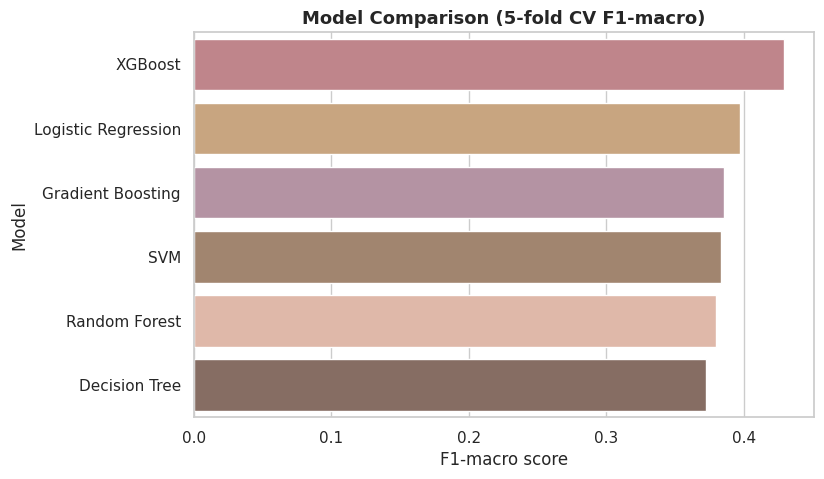

In [97]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="CV F1-macro", y="Model", palette=PALETTE)
plt.title("Model Comparison (5-fold CV F1-macro)", fontsize=13, fontweight="bold")
plt.xlabel("F1-macro score")
plt.show()

In [98]:
# Majority-class baseline, to show the models add real value over a trivial guess
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_scaled, y_train)
dummy_preds = dummy.predict(X_test_scaled)

print("Majority-class baseline accuracy:", round(accuracy_score(y_test, dummy_preds), 3))

Majority-class baseline accuracy: 0.373


# Detailed Evaluation of the Best Model

Best model: XGBoost
              precision    recall  f1-score   support

           1       1.00      0.25      0.40         4
           2       0.32      0.32      0.32        19
           3       0.35      0.42      0.38        31
           4       0.65      0.59      0.62        29

    accuracy                           0.45        83
   macro avg       0.58      0.39      0.43        83
weighted avg       0.48      0.45      0.45        83



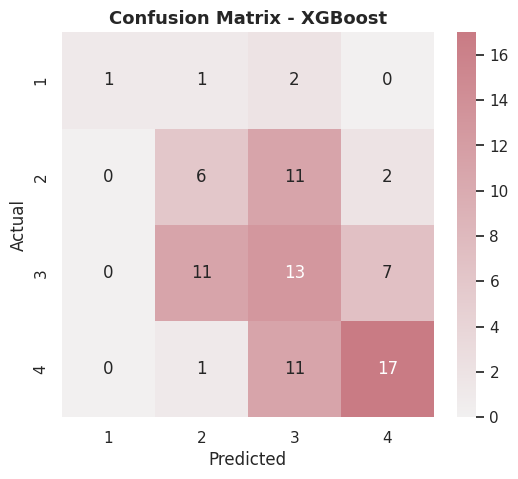

In [99]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print("Best model:", best_model_name)

preds = best_model.predict(X_test_scaled)
y_test_orig = y_test.map(stage_labels)
preds_orig = pd.Series(preds, index=y_test.index).map(stage_labels)

print(classification_report(y_test_orig, preds_orig))

cm = confusion_matrix(y_test_orig, preds_orig)
labels_sorted = sorted(stage_labels.values())

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap=SEQ_CMAP,
            xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.title(f"Confusion Matrix - {best_model_name}", fontsize=13, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##  Hyperparameter Tuning

In [100]:
from sklearn.model_selection import GridSearchCV

# Base (untrained) estimator per model type, used to re-instantiate whichever model won
base_estimators = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss'),
    "SVM": SVC(probability=True, random_state=42),
}

param_grids = {
    "Logistic Regression": {"C": [0.01, 0.1, 1, 10]},
    "Decision Tree": {"max_depth": [None, 5, 10, 15], "min_samples_split": [2, 5, 10]},
    "Random Forest": {"n_estimators": [200, 300, 400], "max_depth": [None, 5, 10, 15], "min_samples_split": [2, 5, 10]},
    "Gradient Boosting": {"n_estimators": [100, 200, 300], "learning_rate": [0.01, 0.05, 0.1], "max_depth": [2, 3, 4]},
    "XGBoost": {"n_estimators": [100, 200, 300], "learning_rate": [0.01, 0.05, 0.1], "max_depth": [3, 4, 5]},
    "SVM": {"C": [0.1, 1, 10], "kernel": ["rbf", "linear"]},
}

grid = GridSearchCV(
    base_estimators[best_model_name],
    param_grids[best_model_name],
    cv=5, scoring='f1_macro', n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

print("Tuned model:", best_model_name)
print("Best params:", grid.best_params_)
print("Best CV F1-macro:", round(grid.best_score_, 3))

tuned_model = grid.best_estimator_
tuned_preds = tuned_model.predict(X_test_scaled)
tuned_preds_orig = pd.Series(tuned_preds, index=y_test.index).map(stage_labels)
print(classification_report(y_test_orig, tuned_preds_orig))

Tuned model: XGBoost
Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
Best CV F1-macro: 0.447
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         4
           2       0.29      0.26      0.28        19
           3       0.35      0.45      0.39        31
           4       0.65      0.59      0.62        29

    accuracy                           0.43        83
   macro avg       0.32      0.33      0.32        83
weighted avg       0.43      0.43      0.43        83



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))




# Feature Importance

/tmp/ipykernel_873/3747172398.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette=PALETTE * 3)
/tmp/ipykernel_873/3747172398.py:9: UserWarning: The palette list has more values (24) than needed (23), which may not be intended.
  sns.barplot(x=importances.values, y=importances.index, palette=PALETTE * 3)


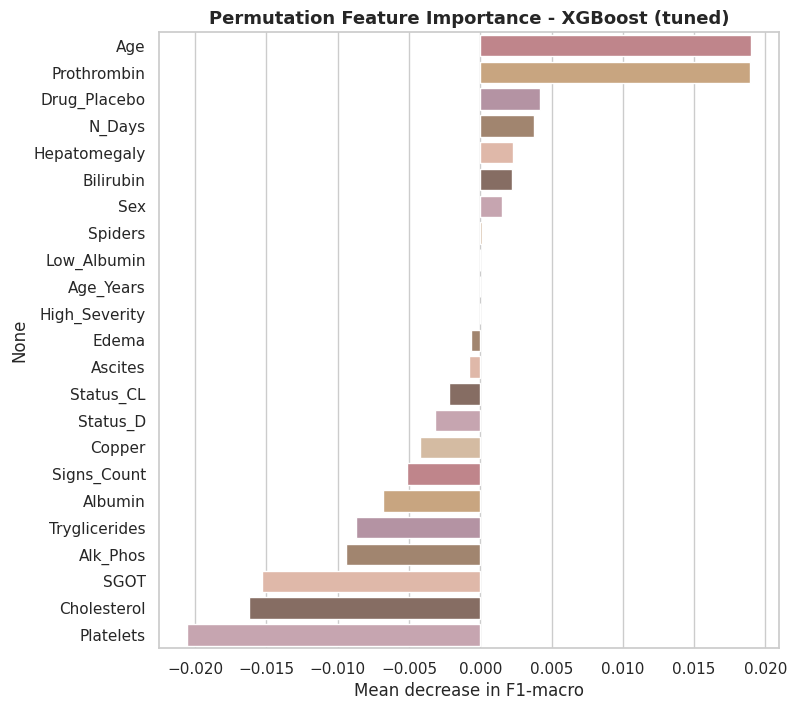

In [101]:
# Permutation importance works for any model type (tree-based or not)
from sklearn.inspection import permutation_importance

perm = permutation_importance(tuned_model, X_test_scaled, y_test, n_repeats=20,
                               random_state=42, scoring='f1_macro')
importances = pd.Series(perm.importances_mean, index=X_test_scaled.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x=importances.values, y=importances.index, palette=PALETTE * 3)
plt.title(f"Permutation Feature Importance - {best_model_name} (tuned)", fontsize=13, fontweight="bold")
plt.xlabel("Mean decrease in F1-macro")
plt.show()

**Interpretation:** if `Status` appears at (or near) the top of this ranking by a wide margin, that is a sign of possible data leakage, since `Status` is determined at roughly the same point in time as `Stage`. Try removing it and retraining, to confirm the model is genuinely learning from clinical/lab features (Bilirubin, Albumin, Copper, etc.) rather than from `Status` alone.

# Model Performance & Limitations

The tuned model reaches a modest accuracy on this 4-class `Stage` prediction task, noticeably above the majority-class baseline computed earlier but still far from perfect. This is expected here, for a few concrete reasons worth stating explicitly in the report/defense rather than treated as a modeling failure:

- **Small dataset**: only ~400 patients total, and even fewer after the 80/20 split (Stage 1 alone has 21 records in the whole dataset).
- **Class imbalance**: Stage 3 and 4 dominate the data, while Stage 1 is rare.
- **Clinically overlapping stages**: adjacent stages (e.g. Stage 2 vs Stage 3) often share similar lab values, so the boundary between them is fuzzy even for clinicians, not just for the model.
- **Public benchmarks on this exact dataset** report comparable accuracy ranges for 4-class Stage prediction, so this result is in line with what is generally achievable with this data, not an implementation bug.